In [1]:
library(tidyverse)
library(data.table)
library(plotly)
library(glmnet)

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘data.table’ was built under R version 4.4.3”

Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The

In [2]:
process_df <- function(df) {
    df <- fread(df)
    df$GO_ID <- as.factor(df$GO_ID)
    df <- df %>% pivot_longer(cols = c("div_d_gamb", "div_d_colu", "div_d_arab"), names_to = "Species", values_to = "Polymorphism")
    df$Species <- as.factor(df$Species)
    df <- df[!is.na(df$Polymorphism) & !is.infinite(df$Polymorphism),]
    df$Level <- as.factor(df$Level)
    return(df)
}

lambda_cv <- function(df){
    df_matrix <- model.matrix(~GO_ID, data=df)

    divergence_vector <- df$Polymorphism
    lambda_seq <- 10^seq(3, -3, by=-0.1)

    cv_output <- cv.glmnet(df_matrix, divergence_vector, alpha=1, lambda=lambda_seq, nfolds=10)
    best_lambda <- cv_output$lambda.min
    return(best_lambda)
}

In [12]:
fdf <- process_df('out/gamb_colu_arab_Function_terms_stats.csv')
fdfG <- fdf[fdf$Species == "div_d_gamb",]
fdfA <- fdf[fdf$Species == "div_d_arab",]
fdfC <- fdf[fdf$Species == "div_d_colu",]
i=1
for (f in list(fdfG, fdfA, fdfC)) {
    mat <- model.matrix(Polymorphism ~ 0 + GO_ID, data=f)
    lass <- glmnet(mat, f$Polymorphism, alpha=1, lambda=0.0015)
    print(i)
    print(as.data.frame(as.matrix(coef(lass))) %>% 
        arrange(desc(s0)))
    i <- i + 1
}
#fdf_matrix <- model.matrix(Polymorphism ~ 0 + GO_ID * Species, data=fdf)
#lass <- glmnet(fdf_matrix, fdf$Polymorphism, alpha=1, lambda=1)
#as.data.frame(as.matrix(coef(lass))) %>% arrange(desc(s0))


[1] 1
                           s0
GO_IDGO:0003923  2.1970885661
GO_IDGO:0016435  1.9626906850
(Intercept)      1.3176385363
GO_IDGO:0004726  1.0315855494
GO_IDGO:0019789  0.8178084377
GO_IDGO:0004582  0.6774872652
GO_IDGO:0004693  0.6700338382
GO_IDGO:0004614  0.6312406447
GO_IDGO:0016833  0.5744673008
GO_IDGO:0004419  0.5744264584
GO_IDGO:0017176  0.5495697399
GO_IDGO:0004648  0.5266891276
GO_IDGO:0004598  0.5266155988
GO_IDGO:0008775  0.5108366462
GO_IDGO:0003986  0.5108032268
GO_IDGO:0061711  0.5087957987
GO_IDGO:0010349  0.4767000844
GO_IDGO:0003874  0.4398261396
GO_IDGO:0016641  0.4373192600
GO_IDGO:0061542  0.4230269253
GO_IDGO:0010420  0.4230059338
GO_IDGO:0004605  0.3940189811
GO_IDGO:0004534  0.3807257182
GO_IDGO:0030366  0.3468974470
GO_IDGO:0036424  0.3445339808
GO_IDGO:0004647  0.3444906712
GO_IDGO:0051751  0.3403700462
GO_IDGO:0061599  0.3243082297
GO_IDGO:0061598  0.3243082252
GO_IDGO:0045735  0.3188740358
GO_IDGO:0035598  0.3097404606
GO_IDGO:0004474  0.3005496744
GO_I

In [9]:
fdf[fdf$Species == "div_d_gamb",]

GO_ID,Gene,Transcript,gene_pi_gamb,gene_pi_colu,gene_pi_arab,aa_pi_gamb,aa_pi_colu,aa_pi_arab,cds_pi_gamb,⋯,ss_d_gamb,ss_d_colu,ss_d_arab,ns_d_gamb,ns_d_colu,ns_d_arab,Level,Depth,Species,Polymorphism
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<int>,<fct>,<dbl>
GO:0005515,AGAP000002,AGAP000002-RA,0.003227809,0.002924822,NA,0.0005401648,0.0001609395,4.573066e-04,0.0009277255,⋯,-2.653548,-2.406324,-2.485779,-2.753961,-2.679489,-2.688417,2,2,div_d_gamb,1.0378412
GO:0005515,AGAP000002,AGAP000002-RB,0.003227809,0.002924822,NA,0.0005401648,0.0001609395,4.573066e-04,0.0009277255,⋯,-2.653548,-2.406324,-2.485779,-2.753961,-2.679489,-2.688417,2,2,div_d_gamb,1.0378412
GO:0005515,AGAP000007,AGAP000007-RA,0.003425350,0.001166049,NA,0.0004324587,0.0001044652,4.208117e-04,0.0011353992,⋯,-2.644807,-2.575448,-2.347921,-2.774236,-2.750270,-2.541279,2,2,div_d_gamb,1.0489371
GO:0005515,AGAP000041,AGAP000041-RA,0.012527698,0.011713160,NA,0.0011851656,0.0008331227,3.804124e-04,0.0028287356,⋯,-2.577208,-2.479060,-2.323333,-2.712175,-2.432657,-2.544539,2,2,div_d_gamb,1.0523694
GO:0005515,AGAP000042,AGAP000042-RB,0.010446726,0.009972618,NA,0.0015553812,0.0013876609,3.805770e-03,0.0027524557,⋯,-2.569887,-2.485483,-2.105397,-2.708644,-2.636945,-2.006979,2,2,div_d_gamb,1.0539936
GO:0005515,AGAP000042,AGAP000042-RA,0.010446726,0.009972618,NA,0.0015553812,0.0013876609,3.805770e-03,0.0027524557,⋯,-2.569887,-2.485483,-2.105397,-2.708644,-2.636945,-2.006979,2,2,div_d_gamb,1.0539936
GO:0005515,AGAP000048,AGAP000048-RA,0.007946722,0.007705017,NA,0.0015866025,0.0013602931,5.448798e-03,0.0031334088,⋯,-2.559321,-2.447704,-1.947469,-2.719388,-2.677033,-1.876495,2,2,div_d_gamb,1.0625428
GO:0005515,AGAP000064,AGAP000064-RA,0.009393894,0.008969121,NA,0.0003040618,0.0001027877,9.695842e-05,0.0020427457,⋯,-2.624849,-2.489545,-2.399081,-2.787311,-2.739850,-2.825670,2,2,div_d_gamb,1.0618938
GO:0005515,AGAP000080,AGAP000080.R648,0.011764737,0.011393683,NA,0.0003717758,0.0001287478,1.549566e-03,0.0011458419,⋯,-2.665381,-2.522784,-1.867358,-2.765801,-2.592645,-2.231696,2,2,div_d_gamb,1.0376758


In [ ]:
cdf <- process_df('out/gamb_colu_arab_Component_terms_stats.csv')
cdf_matrix <- model.matrix(Polymorphism ~ 0 + GO_ID * Species, data=cdf)
lass <- glmnet(cdf_matrix, cdf$Polymorphism, alpha=1, lambda=1)
as.data.frame(as.matrix(coef(lass))) %>% arrange(desc(s0))



,s0
,<dbl>
GO_IDGO.0030915.Speciesdiv_d_colu,322.37962
GO_IDGO.0000775,233.87737
GO_IDGO.0005744,19.92707
X.Intercept.,2.31414
X.Intercept..1,0.00000
GO_IDGO.0000123,0.00000
GO_IDGO.0000124,0.00000
GO_IDGO.0000126,0.00000
GO_IDGO.0000127,0.00000


In [127]:
pdf <- process_df('out/gamb_colu_arab_Process_terms_stats.csv')
pdf_matrix <- model.matrix(Polymorphism ~ 0 + GO_ID * Species, data=pdf)
lass <- glmnet(pdf_matrix, pdf$Polymorphism, alpha=1, lambda=1)
as.data.frame(as.matrix(coef(lass))) %>% arrange(desc(s0))


,s0
,<dbl>
GO_IDGO:0016925:Speciesdiv_d_colu,876.878643
GO_IDGO:0000724:Speciesdiv_d_colu,173.944674
GO_IDGO:0045454:Speciesdiv_d_colu,142.091463
GO_IDGO:0006325,17.757256
GO_IDGO:0006351,14.031137
(Intercept),1.893484
GO_IDGO:0000012,0.000000
GO_IDGO:0000027,0.000000
GO_IDGO:0000028,0.000000


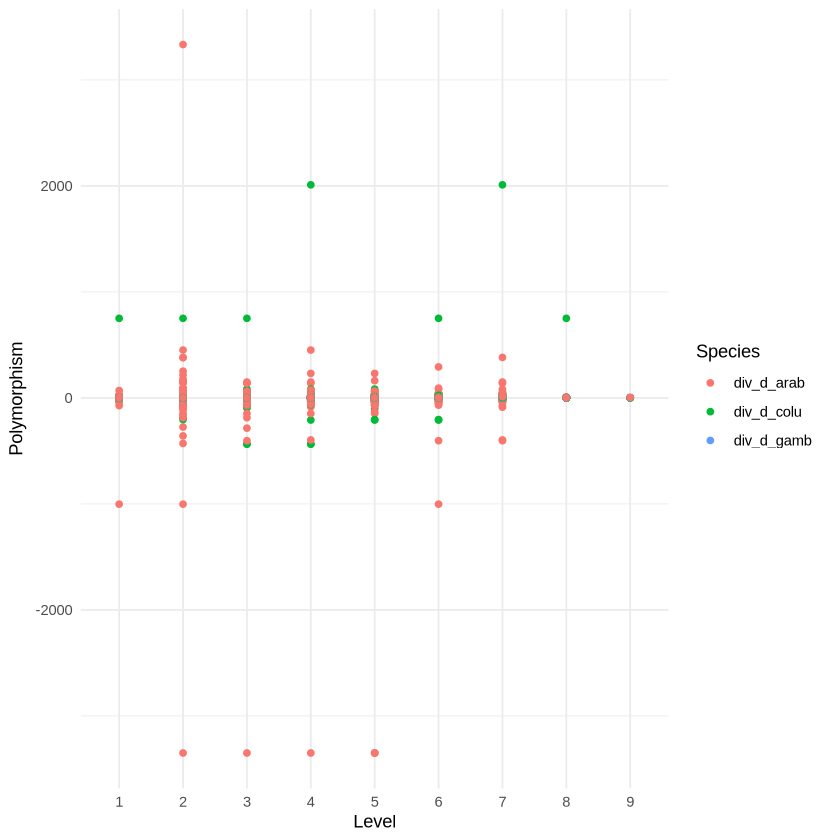

In [102]:
ggplot(fdf, aes(x=Level, y=Polymorphism, color=Species)) +
  geom_point() +
  theme_minimal()# + theme(legend.position = "none")

In [86]:
Fgodf[is.na(Fgodf$Polymorphism),]$Polymorphism <- 0
Fgodf[is.infinite(Fgodf$Polymorphism),]$Polymorphism <- 0

In [88]:
# lasso regression

Fgodf_matrix <- model.matrix(~GO_ID, data=Fgodf)

divergence_vector <- Fgodf$Polymorphism
lambda_seq <- 10^seq(3, -3, by=-0.1)

# split data into test and train
set.seed(666)
train = sample(1:nrow(Fgodf_matrix), nrow(Fgodf_matrix)/2)
xtest = (-train)
ytest = divergence_vector[xtest]

cv_output <- cv.glmnet(Fgodf_matrix, divergence_vector, alpha=1, lambda=lambda_seq, nfolds=10)
best_lambda <- cv_output$lambda.min
best_lambda

[1] 1000

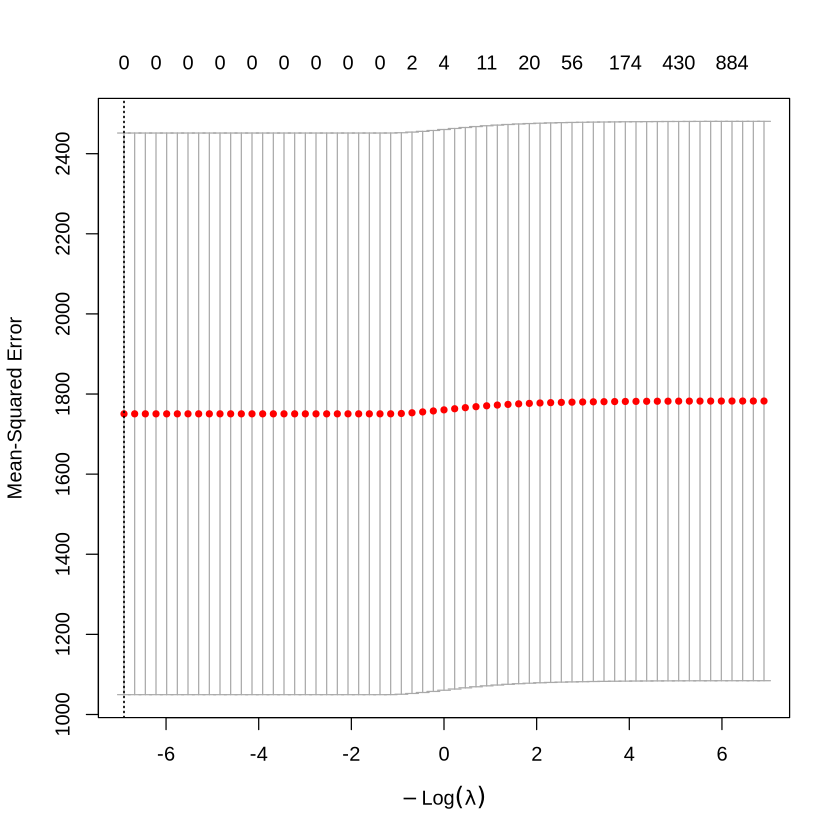

In [89]:
plot(cv_output)

In [94]:
lasso_best <- glmnet(Fgodf_matrix, divergence_vector, alpha=1, lambda=0.1)

In [95]:
as.data.frame(as.matrix(coef(lasso_best))) %>% arrange(desc(s0))

,s0
,<dbl>
GO_IDGO.0019789,160.7366858
GO_IDGO.0004571,56.3619256
GO_IDGO.0030234,19.2653237
GO_IDGO.0004970,6.5471252
GO_IDGO.0005385,3.8828757
GO_IDGO.0031409,2.1318221
GO_IDGO.0030620,2.0907948
GO_IDGO.0015276,1.9154972
GO_IDGO.0016798,1.8760908


In [27]:
Pgodf <- fread('out/gamb_colu_arab_Process_terms_stats.csv')
colnames(Pgodf)

[1] "GO_ID"           "Gene"            "Transcript"      "gene_pi_gamb"   
 [5] "gene_pi_colu"    "gene_pi_arab"    "aa_pi_gamb"      "aa_pi_colu"     
 [9] "aa_pi_arab"      "cds_pi_gamb"     "cds_pi_colu"     "cds_pi_arab"    
[13] "ss_pi_gamb"      "ss_pi_colu"      "ss_pi_arab"      "ns_pi_gamb"     
[17] "ns_pi_colu"      "ns_pi_arab"      "gene_theta_gamb" "gene_theta_colu"
[21] "gene_theta_arab" "aa_theta_gamb"   "aa_theta_colu"   "aa_theta_arab"  
[25] "cds_theta_gamb"  "cds_theta_colu"  "cds_theta_arab"  "ss_theta_gamb"  
[29] "ss_theta_colu"   "ss_theta_arab"   "ns_theta_gamb"   "ns_theta_colu"  
[33] "ns_theta_arab"   "gene_d_gamb"     "gene_d_colu"     "gene_d_arab"    
[37] "aa_d_gamb"       "aa_d_colu"       "aa_d_arab"       "cds_d_gamb"     
[41] "cds_d_colu"      "cds_d_arab"      "ss_d_gamb"       "ss_d_colu"      
[45] "ss_d_arab"       "ns_d_gamb"       "ns_d_colu"       "ns_d_arab"      
[49] "div_d_gamb"      "div_d_colu"      "div_d_arab"      "Level"          
[53] "Depth"

Warning message:
“Removed 234 rows containing missing values or values outside the scale range
(`geom_point()`).”


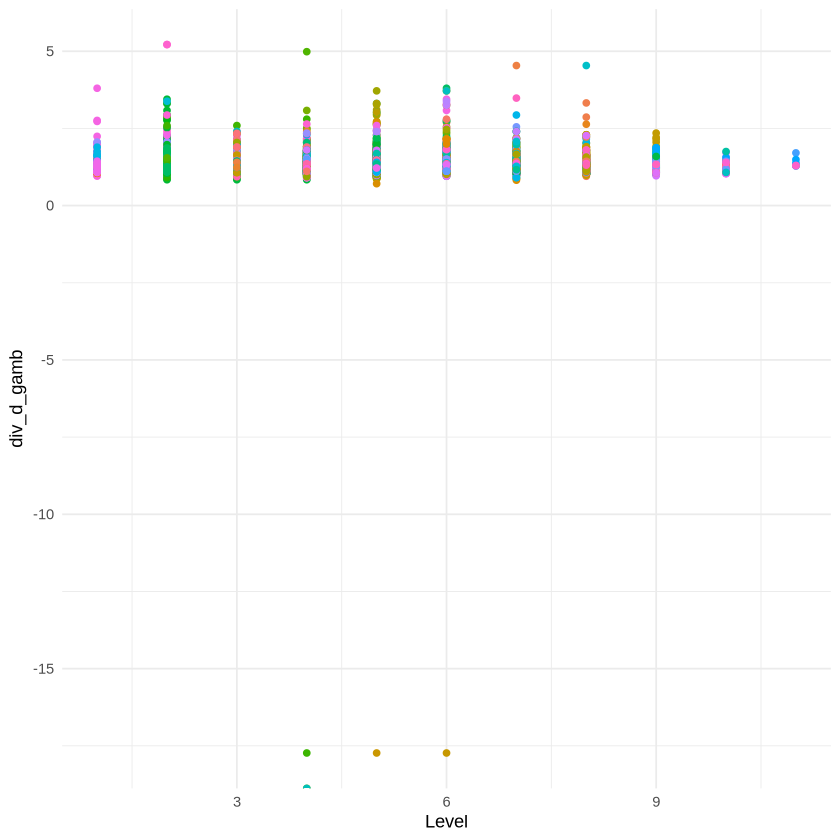

In [7]:
ggplot(Pgodf, aes(x=Level, y=div_d_gamb, color=GO_ID)) +
  geom_point() +
  theme_minimal() + theme(legend.position = "none")

In [28]:
Pgodf <- Pgodf[!is.na(Pgodf$div_d_gamb) & !is.infinite(Pgodf$div_d_gamb),]
Pgodf$Level <- as.factor(Pgodf$Level)

In [73]:
# lasso regression

Pgodf_matrix <- model.matrix(~GO_ID, data=Pgodf)
divergence_vector <- Pgodf$div_d_gamb
lambda_seq <- 10^seq(1, -1, by=-0.1)

# split data into test and train
set.seed(666)
train = sample(1:nrow(Pgodf_matrix), nrow(Pgodf_matrix)/2)
xtest = (-train)
ytest = divergence_vector[xtest]

cv_output <- cv.glmnet(Pgodf_matrix, divergence_vector, alpha=1, lambda=lambda_seq, nfolds=100)
best_lambda <- cv_output$lambda.min
best_lambda

[1] 10

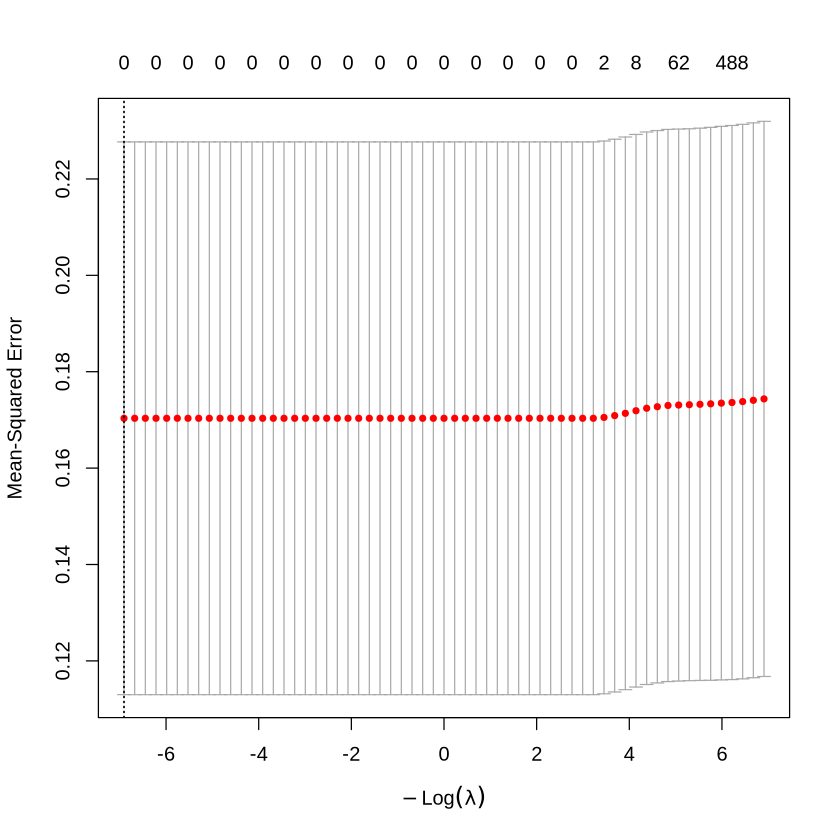

In [33]:
plot(cv_output)

In [45]:
ls(cv_output)
cv_output$cvm

[1] "call"       "cvlo"       "cvm"        "cvsd"       "cvup"      
 [6] "glmnet.fit" "index"      "lambda"     "lambda.1se" "lambda.min"
[11] "name"       "nzero"

[1] 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373
 [8] 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373
[15] 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373
[22] 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373
[29] 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373
[36] 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373 0.1703373
[43] 0.1703373 0.1703373 0.1703373 0.1705149 0.1708924 0.1713653 0.1719027
[50] 0.1724207 0.1727373 0.1729929 0.1730813 0.1731526 0.1732387 0.1733343
[57] 0.1734810 0.1736118 0.1738022 0.1740701 0.1743602

In [78]:
lasso_best <- glmnet(Pgodf_matrix, divergence_vector, alpha=1, lambda=0.01)

In [79]:
as.data.frame(as.matrix(coef(lasso_best))) %>% arrange(desc(s0))

,s0
,<dbl>
X.Intercept.,1.31402566
GO_IDGO.0070476,1.12954937
GO_IDGO.0019079,1.02848695
GO_IDGO.0016925,0.85424003
GO_IDGO.0006891,0.54266051
GO_IDGO.0000076,0.44625477
GO_IDGO.0050830,0.24027092
GO_IDGO.0000724,0.16275386
GO_IDGO.0006506,0.14862061


In [50]:
Cgodf <- fread('out/gamb_colu_arab_Component_terms_stats.csv')
colnames(Cgodf)

[1] "GO_ID"           "Gene"            "Transcript"      "gene_pi_gamb"   
 [5] "gene_pi_colu"    "gene_pi_arab"    "aa_pi_gamb"      "aa_pi_colu"     
 [9] "aa_pi_arab"      "cds_pi_gamb"     "cds_pi_colu"     "cds_pi_arab"    
[13] "ss_pi_gamb"      "ss_pi_colu"      "ss_pi_arab"      "ns_pi_gamb"     
[17] "ns_pi_colu"      "ns_pi_arab"      "gene_theta_gamb" "gene_theta_colu"
[21] "gene_theta_arab" "aa_theta_gamb"   "aa_theta_colu"   "aa_theta_arab"  
[25] "cds_theta_gamb"  "cds_theta_colu"  "cds_theta_arab"  "ss_theta_gamb"  
[29] "ss_theta_colu"   "ss_theta_arab"   "ns_theta_gamb"   "ns_theta_colu"  
[33] "ns_theta_arab"   "gene_d_gamb"     "gene_d_colu"     "gene_d_arab"    
[37] "aa_d_gamb"       "aa_d_colu"       "aa_d_arab"       "cds_d_gamb"     
[41] "cds_d_colu"      "cds_d_arab"      "ss_d_gamb"       "ss_d_colu"      
[45] "ss_d_arab"       "ns_d_gamb"       "ns_d_colu"       "ns_d_arab"      
[49] "div_d_gamb"      "div_d_colu"      "div_d_arab"      "Level"          
[53] "Depth"

Warning message:
“Removed 232 rows containing missing values or values outside the scale range
(`geom_point()`).”


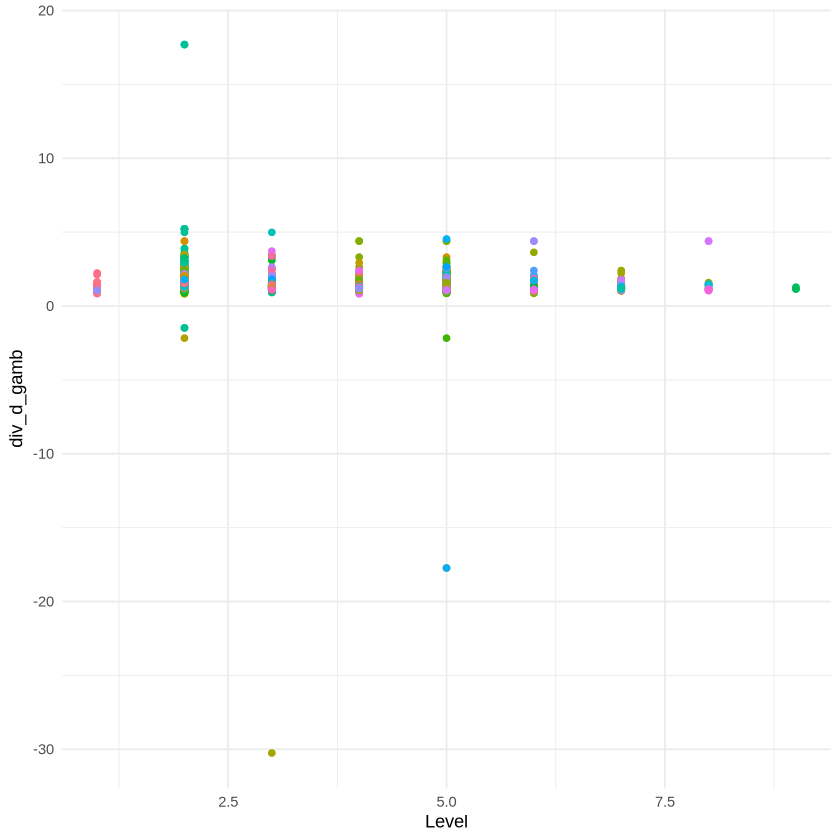

In [51]:
ggplot(Cgodf, aes(x=Level, y=div_d_gamb, color=GO_ID)) +
  geom_point() +
  theme_minimal() + theme(legend.position = "none")

In [52]:
Cgodf <- Cgodf[!is.na(Cgodf$div_d_gamb) & !is.infinite(Cgodf$div_d_gamb),]
Cgodf$Level <- as.factor(Cgodf$Level)

In [53]:
# lasso regression

Cgodf_matrix <- model.matrix(~GO_ID, data=Cgodf)
divergence_vector <- Cgodf$div_d_gamb
lambda_seq <- 10^seq(1, -1, by=-0.1)

# split data into test and train
set.seed(666)
train = sample(1:nrow(Cgodf_matrix), nrow(Cgodf_matrix)/2)
xtest = (-train)
ytest = divergence_vector[xtest]

cv_output <- cv.glmnet(Cgodf_matrix, divergence_vector, alpha=1, lambda=lambda_seq, nfolds=100)
best_lambda <- cv_output$lambda.min
best_lambda

[1] 10

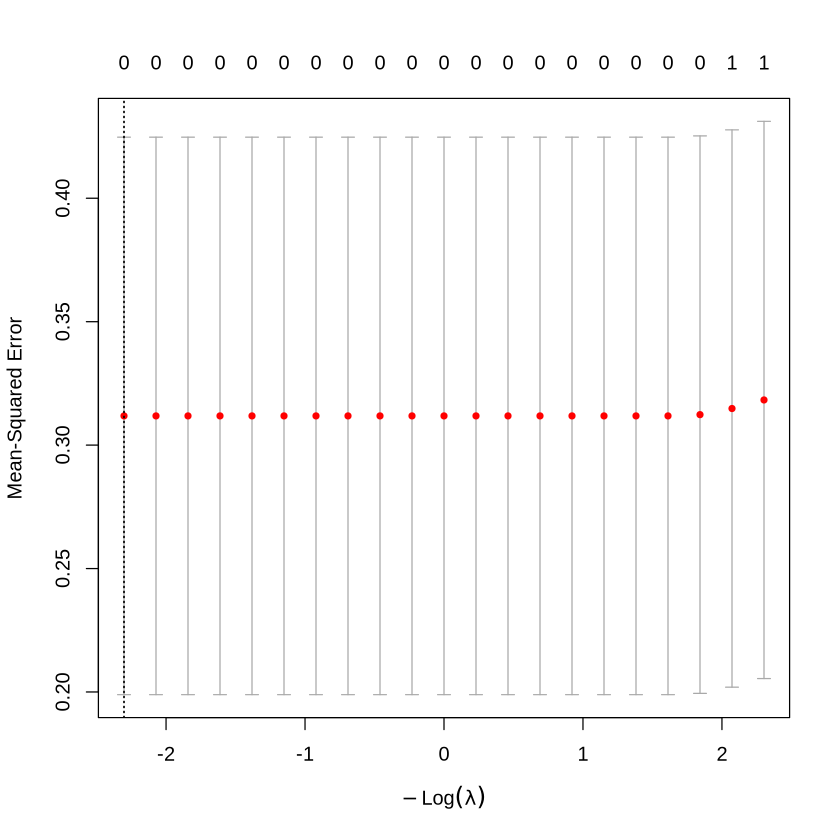

In [54]:
plot(cv_output)

In [69]:
lasso_best <- glmnet(Cgodf_matrix, divergence_vector, alpha=1, lambda=0.01)

In [70]:
as.data.frame(as.matrix(coef(lasso_best))) %>% arrange(desc(s0))

,s0
,<dbl>
GO_IDGO.0033018,2.34081664
GO_IDGO.0042470,2.34081664
X.Intercept.,1.33262152
GO_IDGO.0008541,0.90156817
GO_IDGO.0017119,0.38850538
GO_IDGO.0031417,0.30274682
GO_IDGO.0071986,0.29002897
GO_IDGO.0045121,0.05271176
GO_IDGO.0042765,0.05120862
